In [1]:
import sys

sys.path.append("../src/")

In [2]:
from constants import INPT_VARS, EXTRA_VARS, OUT_VARS, GLOBAL_COMBINED_STATS
import hydra
from hydra.utils import instantiate
from pathlib import Path
import os
from matplotlib.animation import FuncAnimation
import matplotlib.pyplot as plt
import logging

from utils.data_utils import (
    get_wet_mask,
    get_train_test_ranges,
    gen_data_in_test,
    gen_data_out_test,
    data_CNN_Lateral,
    data_CNN_Dynamic,
    gen_data_025_lateral,
    gen_data_global_new,
)
from utils.eval_utils import (
    generate_model_rollout,
    compute_mean,
    compute_var,
    compute_corrs_area,
    compute_rmse,
    compute_corrs,
    compute_KE,
    compute_time_spec,
    compute_ACC,
    compute_nino34,
    compute_amo,
    gen_KE_spectrum,
    gen_KE,
    gen_KE_range,
    gen_value_range,
    gen_enstrophy_spectrum,
    gen_enstrophy,
    compute_corrs_single,
    compute_ACC_single,
    compute_RMSE_single,
    compute_mean_single,
)
from utils.subgrid_utils import get_area_tensor
from utils.climate_utils import compute_laplacian_wet
from utils.plot_utils import (
    plot_short_time_stats,
    plot_long_time_stats,
    plot_map,
    plot_error_map,
    plot_both_error_map,
    plot_metrics_KE_spectrum,
    plot_metrics_KE,
    plot_metrics_enstrophy_spectrum,
    plot_metrics_entrophy,
    plot_metrics_corr,
    plot_metrics_rmse,
    plot_metrics_acc,
    plot_metrics_mean,
    plot_metrics_pdf,
    get_initial_snapshot_fig,
    plot_region_based_metric,
    plot_diff_map,
)

import numpy as np
import torch
import xarray as xr
import copy

from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
import copy
from datetime import datetime
import os

In [17]:
import copy


class data_CNN_Dynamic(torch.utils.data.Dataset):

    def __init__(
        self, data_in, data_out, wet, area, noise_std, std_dict=None, device="cuda"
    ):
        super().__init__()
        self.device = device
        num_inputs = data_in.shape[3]
        num_outputs = data_out.shape[3]
        self.size = data_in.shape[0]
        self.area = area
        self.noise_std = noise_std

        data_in = np.nan_to_num(data_in)
        data_out = np.nan_to_num(data_out)

        if std_dict is None:
            std_data = np.nanstd(data_in, axis=(0, 1, 2))
            mean_data = np.nanmean(data_in, axis=(0, 1, 2))
            std_label = np.nanstd(data_out, axis=(0, 1, 2))
            mean_label = np.nanmean(data_out, axis=(0, 1, 2))
        else:
            std_data = std_dict["s_in"]
            mean_data = std_dict["m_in"]
            std_label = std_dict["s_out"]
            mean_label = std_dict["m_out"]

        self.wet = wet

        for i in range(num_inputs):
            data_in[:, :, :, i] = (data_in[:, :, :, i] - mean_data[i]) / std_data[i]

        for i in range(num_outputs):
            data_out[:, :, :, i] = (data_out[:, :, :, i] - mean_label[i]) / std_label[i]

        data_in = torch.from_numpy(data_in).type(torch.float32).to(device="cpu")
        data_out = torch.from_numpy(data_out).type(torch.float32).to(device="cpu")

        std_dict = {
            "s_in": std_data,
            "s_out": std_label,
            "m_in": mean_data,
            "m_out": mean_label,
        }

        if wet == None:
            self.input = torch.swapaxes(torch.swapaxes(data_in, 1, 3), 2, 3)
            self.output = torch.swapaxes(torch.swapaxes(data_out, 1, 3), 2, 3)

        else:
            self.input = torch.mul(
                torch.swapaxes(torch.swapaxes(data_in, 1, 3), 2, 3), wet
            )
            self.output = torch.mul(
                torch.swapaxes(torch.swapaxes(data_out, 1, 3), 2, 3), wet
            )

        self.norm_vals = std_dict

    def set_device(self, device):
        self.device = device

    def __len__(self):
        # Number of data point we have. Alternatively self.data.shape[0], or self.label.shape[0]
        return self.size

    def __getitem__(self, idx):
        # Return the idx-th data point of the dataset
        # If we have multiple things to return (data point and label), we can return them as tuple
        data_in = self.input[idx]
        label = self.output[idx]

        for n in range(data_in.shape[0]):
            for c in range(data_in.shape[1]):
                if c > 2:
                    noise = torch.randn_like(data_in[n, c]) * self.noise_std
                    noise = noise - (self.area * noise).sum() / self.area.sum()
                    assert (self.area * noise).sum() / self.area.sum() < 1e-7
                    data_in[n, c] = data_in[n, c] + noise

        return data_in.to(device=self.device), label.to(device=self.device), noise

In [18]:
class Eval:
    def __init__(self, args, noise_std):
        # Getting input, extra input and output
        self.inputs = INPT_VARS[args.exp_num_in]
        self.extra_in = EXTRA_VARS[args.exp_num_extra]
        self.outputs = OUT_VARS[args.exp_num_out]

        self.str_in = "".join([i + "_" for i in self.inputs])
        self.str_ext = "".join([i + "_" for i in self.extra_in])
        self.str_out = "".join([i + "_" for i in self.outputs])

        print("inputs: " + self.str_in)
        print("extra inputs: " + self.str_ext)
        print("outputs: " + self.str_out)

        self.N_atm = len(self.extra_in)  # Number of atmosphere variables
        self.N_in = len(self.inputs)
        if args.lateral:
            self.N_extra = (
                self.N_atm + self.N_in
            )  # Number of atmosphere variables + Lateral boundary variables
        else:
            self.N_extra = self.N_atm  # Number of atmosphere variables
        self.N_out = len(self.outputs)

        self.num_in = int((args.hist + 1) * self.N_in + self.N_extra)

        print("Number of inputs: ", self.num_in)  # 3 (ocean speeds + ocean temp)(t) +
        # 3 (atm wind stresses + atm temp)(t) +
        # 3 (boundary ocean speeds + boundary ocean temp)(t) -> 3 (ocean speeds + ocean temp)(t+1)
        print("Number of outputs: ", self.N_out)  # 3

        # Post-fix strings
        self.str_train = (
            "steps_"
            + str(args.steps)
            + "_"
            + args.train_region
            + "_Test_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "_out"
            + self.str_out
            + "N_train_4000"
            + "_Lateral_Data_025_no_smooth"
        )
        self.str_save = (
            "steps_"
            + str(args.steps)
            + "_"
            + args.train_region
            + "_"
            + args.region
            + "_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "N_samples_"
            + str(args.N_samples)
        )
        self.post_model_name = (
            "Train_"
            + args.train_region
            + "_Test_"
            + args.region
            + "_Test_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "_out"
            + self.str_in
            + "N_train_"
            + str(args.N_samples)
            + "_Lateral_Data_025_no_smooth"
        )
        self.post_pred_name = (
            args.region
            + "_in_"
            + self.str_in
            + "ext_"
            + self.str_ext
            + "N_samples_"
            + str(args.N_samples)
        )

        # Getting start and end indices of train and test
        s_train, e_train, e_test = get_train_test_ranges(
            args.N_samples, args.N_val, args.lag, args.hist, args.interval
        )

        # Saving data
        print("Getting inputs")
        if "global_1" == args.region:
            inputs, extra_in, outputs = gen_data_global_new(
                self.inputs, self.extra_in, self.outputs, args.lag
            )
        elif "global_2x" == args.region:
            inputs, extra_in, outputs = gen_data_global_new(
                self.inputs, self.extra_in, self.outputs, args.lag, run_type="2x"
            )
        elif "global_4x" == args.region:
            inputs, extra_in, outputs = gen_data_global_new(
                self.inputs, self.extra_in, self.outputs, args.lag, run_type="4x"
            )
        else:
            raise NotImplementedError

        print("Calculating mask tensors")
        self.wet, self.wet_nan = get_wet_mask(inputs, "cpu")
        self.wet_bool = np.array(self.wet.cpu()).astype(bool)
        wet_lap = compute_laplacian_wet(self.wet_nan, 4)  # hardcoded
        wet_lap = xr.where(wet_lap == 0, 1, np.nan)
        self.wet_lap = np.nan_to_num(wet_lap)
        print("Wet resolution:", self.wet.shape)

        self.time_vec = inputs[0].time.data

        self.time_test = self.time_vec[e_test : (e_test + args.lag * args.N_test)]

        # Getting area tensor
        print("Computing area tensor")
        self.grids = xr.open_dataset(
            "/scratch/as15415/Data/CM2x_grids/Grid_New.nc"
        ).rename({"dx": "dxu", "dy": "dyu"})

        self.area = torch.from_numpy(self.grids["area_C"].to_numpy()).to(device="cpu")
        self.area /= self.area.max()
        self.dx = self.grids["dxu"].to_numpy()
        self.dy = self.grids["dyu"].to_numpy()

        print("Loading Train data")
        train_data = torch.load(
            Path(args.data_dir) / "train_data_cnn_{0}.pt".format(self.str_train),
            map_location=torch.device("cpu"),
        )
        self.train_data = train_data

        if args.save_test_data:
            print("Saving data")
            data_in_test = gen_data_in_test(
                0, e_test, args.N_test, args.lag, args.hist, inputs, extra_in
            )
            data_out_test = gen_data_out_test(
                0, e_test, args.N_test, args.lag, args.hist, outputs
            )
            if "global" in args.region:
                norm_vals = train_data.norm_vals
                if "combined" in args.train_region:
                    assert len(norm_vals) == len(GLOBAL_COMBINED_STATS) and all(
                        np.array_equal(norm_vals[k], GLOBAL_COMBINED_STATS[k])
                        for k in norm_vals
                    )
                self.test_data = data_CNN_Dynamic(
                    data_in_test,
                    data_out_test,
                    self.wet.to(device="cpu"),
                    self.area,
                    noise_std,
                    norm_vals,
                    device=args.device,
                )
                # del train_data
            else:
                raise NotImplementedError()
            torch.save(
                self.test_data,
                Path(args.data_dir)
                / "test_{1}_data_cnn_{0}.pt".format(self.str_save, noise_std * 100),
            )

        else:
            print("Loading test data")
            self.test_data = torch.load(
                Path(args.data_dir)
                / "test_{1}_data_cnn_{0}.pt".format(self.str_save, noise_std * 100)
            )

        # Model
        print("Loading model " + args.network)
        if "swin" in args.network.lower():
            model = instantiate(
                args.swin,
                in_channels=self.num_in,
                output_channels=self.N_in,
                pretrain_img_size=[*self.test_data[0][0].shape[1:]],
                wet=self.wet.cuda(),
            )
        elif "unet" in args.network.lower():
            model = instantiate(args.unet, wet=self.wet.cuda())

        full_model_path = args.ckpt_path
        self.full_model_name = args.network + "_" + self.post_model_name
        self.output_channels = model.output_channels

        model = model.to(args.device)
        self.ckpt_path = args.ckpt_path
        self.model = model

        # Stats
        self.mean_out = self.test_data.norm_vals["m_out"]
        self.std_out = self.test_data.norm_vals["s_out"]
        self.mean_in = self.test_data.norm_vals["m_in"]
        self.std_in = self.test_data.norm_vals["s_in"]

        # clim
        self.clim = None
        if args.save_clim_data:
            print("Saving clim")
            clim = np.zeros((366, *self.wet.shape, 3))
            for i in range(self.N_out):
                clim[:, :, :, i] = (
                    outputs[i].groupby("time.dayofyear").mean("time").data
                )
            torch.save(
                clim,
                Path(args.data_dir) / "clim_cnn_{0}.pt".format(self.str_save),
            )

        else:
            print("Loading clim")
            clim = torch.load(
                Path(args.data_dir) / "clim_cnn_{0}.pt".format(self.str_save)
            )

        self.clim = clim

        self.pred_model_path = Path(args.path_dir) / self.full_model_name
        if not os.path.isdir(self.pred_model_path):
            os.makedirs(self.pred_model_path)

        self.Nb = args.Nb
        self.hist = args.hist
        self.lag = args.lag
        self.N_test = args.N_test
        self.N_samples = args.N_samples
        self.output_dir = args.output_dir
        self.region = args.region
        self.steps = args.steps
        self.network = args.model_name_replace
        self.inputs = inputs

        self.pred_region = args.region
        self.pred_names = args.pred_names if args.pred_names else []
        self.pred_paths = args.pred_paths if args.pred_paths else []

        self.JUPYTER_MODE = False

    def send_data_to_cpu(self):
        self.test_data.set_device(device="cpu")

In [71]:
# G1, G1
# ConvNext UNet
# 5% noise
with initialize_config_dir(
    version_base=None,
    config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs",
):
    args = compose(
        config_name="exp/eval_unet_global",
        overrides=[
            "output_dir=./temp/{0}_conv_multiseed_g1g1_noise_TEST_5".format(
                str(datetime.now())[:10]
            ),
            "model_name_replace=5% noise",
            "train_region=global_1",
            "region=global_1",
            "run_gen_pred=True",  # Multi-Seed Generation
            "save_test_data=False",
            "save_clim_data=False",
            "network=ConvNext UNet Train1Eval1 5%Noise_TEST",
            "ckpt_path=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-11-foundation_train_convnextunet_global_1/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_1_seed100/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
                    /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_1_seed200/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
            "pred_names=null",
            "pred_paths=null",
        ],
    )
if not os.path.exists(args.output_dir):
    os.mkdir(args.output_dir)

e = Eval(args, noise_std=0.05)

# 25% noise
# with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
#     args = compose(config_name="exp/eval_unet_global", overrides=[
#         "output_dir=./temp/{0}_conv_multiseed_g1g1_noise_TEST_25".format(str(datetime.now())[:10]),
#         "model_name_replace=25% noise",
#         "train_region=global_1",
#         "region=global_1",
#         "save_test_data=False",
#         "run_gen_pred=False", # Multi-Seed Generation
#         "network=ConvNext UNet Train1Eval1 25%Noise_TEST",
#         "ckpt_path=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-11-foundation_train_convnextunet_global_1/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_1_seed100/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_1_seed200/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#         "pred_names=null",
#         "pred_paths=null"
#     ])
# if not os.path.exists(args.output_dir):
#     os.mkdir(args.output_dir)

# e = Eval(args, noise_std=0.25)

# 100%
# with initialize_config_dir(version_base=None, config_dir="/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/configs"):
#     args = compose(config_name="exp/eval_unet_global", overrides=[
#         "output_dir=./temp/{0}_conv_multiseed_g1g1_noise_TEST_100".format(str(datetime.now())[:10]),
#         "model_name_replace=100% noise",
#         "train_region=global_1",
#         "region=global_1",
#         "save_test_data=False",
#         "run_gen_pred=False", # Multi-Seed Generation
#         "network=ConvNext UNet Train1Eval1 100%Noise_TEST",
#         "ckpt_path=[/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/train/2024-05-11-foundation_train_convnextunet_global_1/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_1_seed100/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt,\
#                     /scratch/sg7761/m2lines/Ocean_Emulator/train/2024-05-21-foundation_train_convnextunet_global_1_seed200/next/saved_nets/convnextunet_best_steps_4_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth.pt]",
#         "pred_names=['0% Noise', '5% Noise', '25% Noise']",
#         "pred_paths=['/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Train1Eval1_Train_global_1_Test_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth',\
#                     '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Train1Eval1 5%Noise_Train_global_1_Test_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth',\
#                     '/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/Preds/ConvNext UNet Train1Eval1 25%Noise_Train_global_1_Test_global_1_Test_in_u_v_T_ext_tau_u_tau_v_t_ref__outu_v_T_N_train_4000_Lateral_Data_025_no_smooth']"
#     ])
# if not os.path.exists(args.output_dir):
#     os.mkdir(args.output_dir)

# e = Eval(args, noise_std=1.0)

inputs: u_v_T_
extra inputs: tau_u_tau_v_t_ref_
outputs: u_v_T_
Number of inputs:  6
Number of outputs:  3
Getting inputs
Calculating mask tensors


/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lat' to 'yt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})
/scratch/sd5313/M2Lines/emulator/Ocean_Emulator/notebooks/../src/utils/data_utils.py:1049: UserWarning: rename 'lon' to 'xt_ocean' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  data_atmos = data_atmos.rename({"lat":"yt_ocean","lon":"xt_ocean"})


Wet resolution: torch.Size([180, 360])
Computing area tensor
Loading Train data
Loading test data
Loading model ConvNext UNet Train1Eval1 5%Noise_TEST
Loading clim


In [90]:
import matplotlib.pyplot as plt

In [94]:
e.test_data[0][2].shape

torch.Size([360])

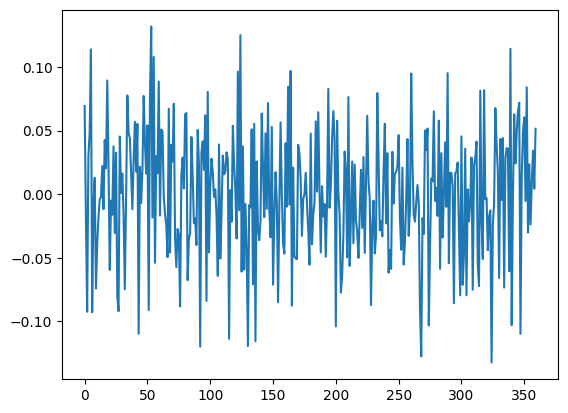

In [91]:
plt.plot(e.test_data[0][2])

In [100]:
e.test_data.input.shape

torch.Size([3000, 6, 180, 360])

In [40]:
(e.test_data[0][0].cpu() == e.test_data.input[0]).all()

tensor(True)

In [99]:
e.test_data.input[0].shape

torch.Size([6, 180, 360])

In [98]:
data_in[0].shape

torch.Size([180, 360])

In [117]:
e.test_data[0][0].shape

torch.Size([6, 180, 360])

In [122]:
import copy

data_in = copy.deepcopy(e.test_data.input[0])
assert len(data_in.shape) == 3
for c in range(data_in.shape[0]):
    if c > 2:
        noise = torch.randn_like(data_in[c]) * 0.05
        assert noise.shape == e.area.shape
        noise = noise - (e.area * noise).sum() / e.area.sum()
        print(noise.shape)
        assert (e.area * noise).sum() / e.area.sum() < 1e-7
        data_in[c] = data_in[c] + noise

print((e.test_data[0][0].cpu() == data_in).all())
print((old_data == data_in).all())
print((e.test_data.input[0] == old_data).all())

torch.Size([180, 360])
torch.Size([180, 360])
torch.Size([180, 360])
tensor(False)
tensor(False)
tensor(False)


In [116]:
(e.test_data[0][0].cpu() == e.test_data.input[0]).all()

tensor(True)

In [39]:
for i in range(100):
    (e.test_data[i][0].cpu() == e.test_data.input[i])

In [15]:
(a == b).all()

tensor(True)

-----

In [81]:
test_data_input = copy.deepcopy(e.test_data.input)

In [82]:
import copy

data_in = e.test_data.input[0]
old_data = copy.deepcopy(data_in)
for n in range(data_in.shape[0]):
    for c in range(data_in.shape[1]):
        if c > 2:
            noise = torch.randn_like(data_in[n, c]) * 0.05
            noise = noise - (e.area * noise).sum() / e.area.sum()
            assert (e.area * noise).sum() / e.area.sum() < 1e-7
            data_in[n, c] = data_in[n, c] + noise

print((e.test_data[0][0].cpu() == data_in).all())
print((old_data == data_in).all())
print((e.test_data.input[0] == old_data).all())

tensor(True)
tensor(False)
tensor(False)


In [83]:
(test_data_input == e.test_data.input).all()

tensor(False)

-----

In [84]:
test_data_input = copy.deepcopy(e.test_data.input)

In [85]:
import copy

data_in = copy.deepcopy(e.test_data.input[0])
old_data = copy.deepcopy(data_in)
for n in range(data_in.shape[0]):
    for c in range(data_in.shape[1]):
        if c > 2:
            noise = torch.randn_like(data_in[n, c]) * 0.05
            noise = noise - (e.area * noise).sum() / e.area.sum()
            assert (e.area * noise).sum() / e.area.sum() < 1e-7
            data_in[n, c] = data_in[n, c] + noise

print((e.test_data[0][0].cpu() == data_in).all())
print((old_data == data_in).all())
print((e.test_data.input[0] == old_data).all())

tensor(False)
tensor(False)
tensor(False)


In [86]:
(test_data_input == e.test_data.input).all()

tensor(False)

In [87]:
e.test_data.input - test_data_input

tensor([[[[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          ...,
          [-0.0111, -0.0154, -0.1039,  ...,  0.0457, -0.0133,  0.0560],
          [-0.0656, -0.0754,  0.0933,  ...,  0.0097, -0.0020, -0.0744],
          [-0.0676,  0.0768, -0.0069,  ..., -0.0293, -0.0369,  0.0317]],

         [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          ...,
          [ 0.0544,  0.0261, -0.0132,  ...,  0.0073, -0.0220,  0.0359],
          [-0.0620, -0.0815, -0.0509,  ...,  0.0327, -0.0466,  0.0046],
          [ 0.0528, -0.0147,  0.0734,  ..., -0.0213,  0.0286,  0.0293]],

         [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  